# 07 - Long Short-Term Memory (LSTM)


---

In the previous notebook, we learned about Recurrent Neural Networks (RNNs).

RNNs introduced memory into NLP, allowing models to process sequential data.

However, RNNs have a major limitation:

They struggle to remember information over long sequences.

In this notebook, we will learn how LSTM solves this problem using memory cells and gates.

## 📜 History

RNNs were a breakthrough because they introduced the concept of memory.

However, researchers observed a serious issue.

Consider this sentence:

"The movie that I watched with my friends during my first year of college was amazing."

To understand the word **amazing**, the model should remember that we are talking about **the movie**.

As sentences became longer, RNNs started forgetting important information from earlier in the sequence.

This problem became known as the **Vanishing Gradient Problem**.

In 1997, researchers **:contentReference[oaicite:0]{index=0}** and **:contentReference[oaicite:1]{index=1}** introduced **Long Short-Term Memory (LSTM)** to solve this issue.

## ❌ Why RNN Was Not Enough

RNN updates its hidden state at every time step.

As more words are processed, information from the beginning of the sentence gradually fades.

Example:

I started learning Artificial Intelligence four years ago...

...

...

Today I built my own chatbot.

When predicting the last word, the RNN may forget:

"I started learning Artificial Intelligence"

This makes it difficult to understand long sequences.

## 💡 Core Idea

LSTM introduces a **Memory Cell**.

Instead of simply replacing the hidden state at every step, LSTM decides:

- What information should be remembered.
- What information should be forgotten.
- What new information should be stored.

It does this using **three gates**:

1. Forget Gate
2. Input Gate
3. Output Gate

## 🧠 Human Analogy

Imagine you are preparing for an exam.

You remember:

- Important formulas ✅
- Important concepts ✅

But you forget:

- Unnecessary details ❌

Your brain naturally decides:

Remember?

Forget?

Update?

LSTM behaves in a similar way.

In [1]:
sentence = "I started learning AI in college"

memory = []

for word in sentence.split():

    memory.append(word)

    print("Current Word:", word)

    print("Memory:", memory)

    print("-"*30)

Current Word: I
Memory: ['I']
------------------------------
Current Word: started
Memory: ['I', 'started']
------------------------------
Current Word: learning
Memory: ['I', 'started', 'learning']
------------------------------
Current Word: AI
Memory: ['I', 'started', 'learning', 'AI']
------------------------------
Current Word: in
Memory: ['I', 'started', 'learning', 'AI', 'in']
------------------------------
Current Word: college
Memory: ['I', 'started', 'learning', 'AI', 'in', 'college']
------------------------------


## 📊 LSTM Architecture

```
Previous Hidden State
          │
          ▼
     Forget Gate
          │
          ▼
      Memory Cell
          │
   ┌──────┼──────┐
   ▼      ▼      ▼
Input   Update  Output
Gate     Cell    Gate
          │
          ▼
New Hidden State
```

The memory cell carries important information across many time steps.

## 🧠 Forget Gate

Question:

What information should be removed?

Example:

Sentence:

"My favorite color was blue when I was five years old."

The age information may not be important later.

The Forget Gate decides what to discard.

## 🧠 Input Gate

Question:

What new information should be stored?

Example:

"I am learning Transformers."

The model should store:

Transformers

because it may be useful later.

## 🧠 Output Gate

Question:

What information should be sent to the next hidden state?

The Output Gate controls what the model reveals at the current time step.

In [2]:
memory = ["I", "love"]

new_word = "AI"

print("Old Memory:", memory)

memory.append(new_word)

print("Updated Memory:", memory)

Old Memory: ['I', 'love']
Updated Memory: ['I', 'love', 'AI']


## ➗ Mathematics

Forget Gate

\[
f_t = \sigma(W_f[h_{t-1},x_t]+b_f)
\]

Input Gate

\[
i_t=\sigma(W_i[h_{t-1},x_t]+b_i)
\]

Candidate Memory

\[
\tilde C_t=\tanh(W_c[h_{t-1},x_t]+b_c)
\]

Memory Update

\[
C_t=f_t*C_{t-1}+i_t*\tilde C_t
\]

Output Gate

\[
o_t=\sigma(W_o[h_{t-1},x_t]+b_o)
\]

Hidden State

\[
h_t=o_t*tanh(C_t)
\]

Don't worry about memorizing these equations.

The important idea is:

Forget → Store → Output.

## Sigmoid Function

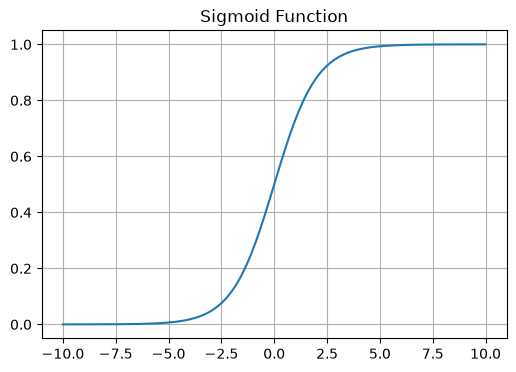

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-10,10,200)

y=1/(1+np.exp(-x))

plt.figure(figsize=(6,4))

plt.plot(x,y)

plt.title("Sigmoid Function")

plt.grid()

plt.show()

### PyTorch LSTM

In [4]:
import torch
import torch.nn as nn

lstm = nn.LSTM(

    input_size=5,

    hidden_size=4,

    batch_first=True

)

print(lstm)

LSTM(5, 4, batch_first=True)


In [5]:
x=torch.randn(1,6,5)

output,(hidden,cell)=lstm(x)

print("Output Shape:",output.shape)

print("Hidden Shape:",hidden.shape)

print("Cell Shape:",cell.shape)

Output Shape: torch.Size([1, 6, 4])
Hidden Shape: torch.Size([1, 1, 4])
Cell Shape: torch.Size([1, 1, 4])


## 📊 Comparison

| Feature | RNN | LSTM |
|---------|-----|------|
| Memory | Hidden State | Hidden + Cell State |
| Long-term Memory | Poor | Excellent |
| Vanishing Gradient | Yes | Much Better |
| Gates | No | Yes |

Hidden State (h)	Cell State (c)
Short-term memory	Long-term memory
Used to produce the current output	Carries important information across many time steps
Passed to the next hidden state	Passed through the cell state pathway
Changes more rapidly	Preserves important information for longer
In an LSTM

At every time step, the LSTM maintains two memories:

            Hidden State (h)
                  │
                  ▼
Word1 → LSTM → Word2 → LSTM → Word3
         │             │
         ▼             ▼
     Cell State (c) ─────────────►
Hidden state (h) is the current output or short-term memory.
Cell state (c) is the long-term memory that flows through the sequence.
Think of reading a book 📖

Suppose you're reading a novel.

Hidden state = What you're currently thinking about after reading the latest page.
Cell state = The important story details you remember from earlier chapters.

For example:

Chapter 1:
Harry is a wizard.

↓

Chapter 20:
Harry fights Voldemort.

When you reach Chapter 20:

Hidden state focuses on the current fight.
Cell state still remembers that Harry is a wizard from Chapter 1.

Without the cell state, the model would likely forget early information.

## ✅ Advantages

- Learns long-term dependencies
- Better memory
- Reduces vanishing gradient
- Excellent for sequential tasks

## ❌ Disadvantages

LSTM is powerful but has drawbacks.

- More parameters
- Slower training
- Sequential computation
- Difficult to parallelize

Researchers wanted something simpler and faster.

This led to **GRU**.

## 🌍 Applications

LSTM has been used for:

- Machine Translation
- Speech Recognition
- Text Generation
- Sentiment Analysis
- Time-Series Forecasting
- Handwriting Recognition

## ✅ Summary

Today I learned:

- Why RNN fails on long sequences.
- What the Vanishing Gradient Problem is.
- How LSTM uses a Memory Cell.
- The purpose of Forget, Input, and Output Gates.
- How to create an LSTM in PyTorch.